In [3]:
%matplotlib ipympl

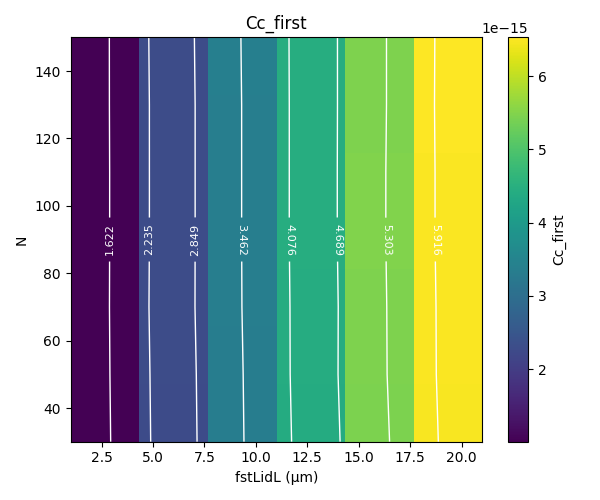

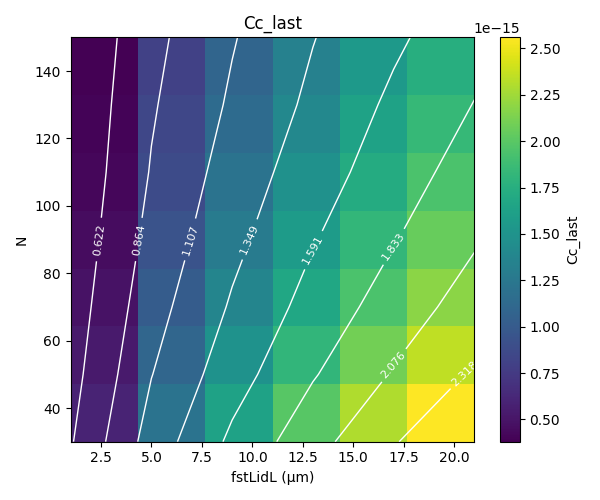

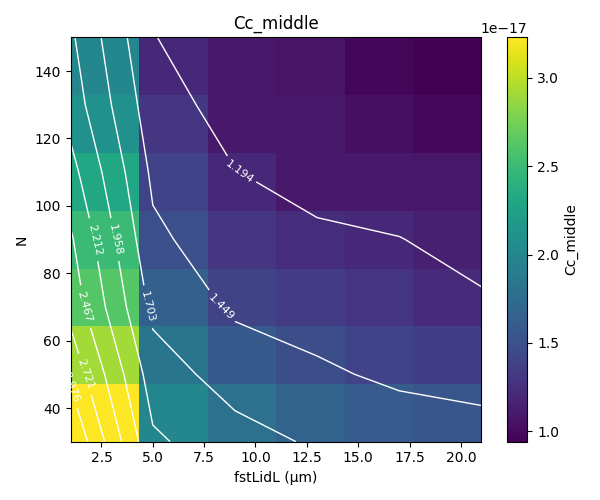

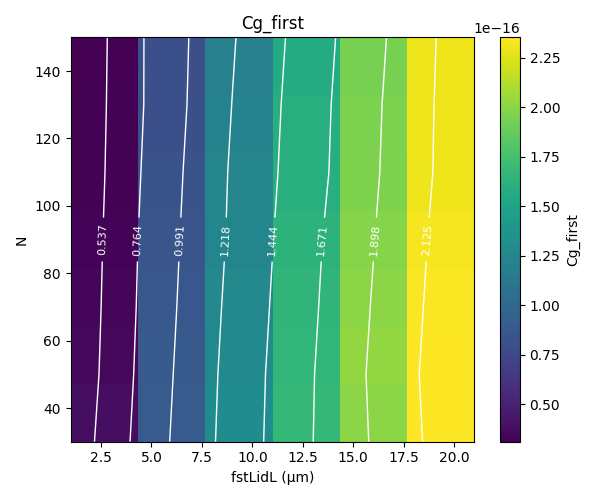

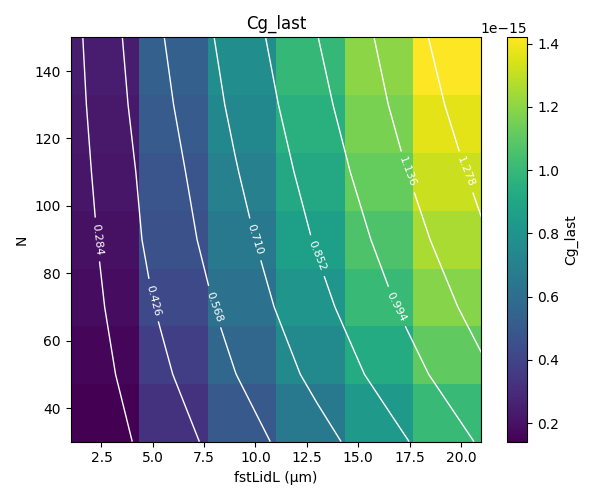

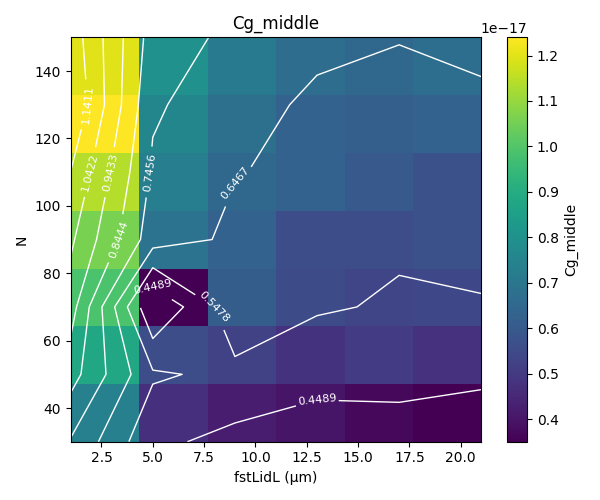

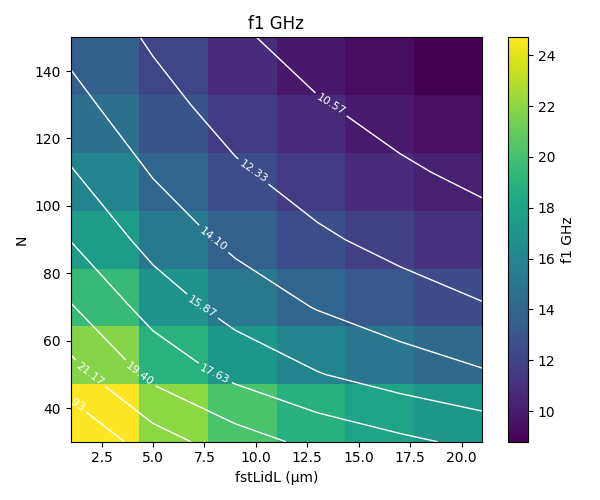

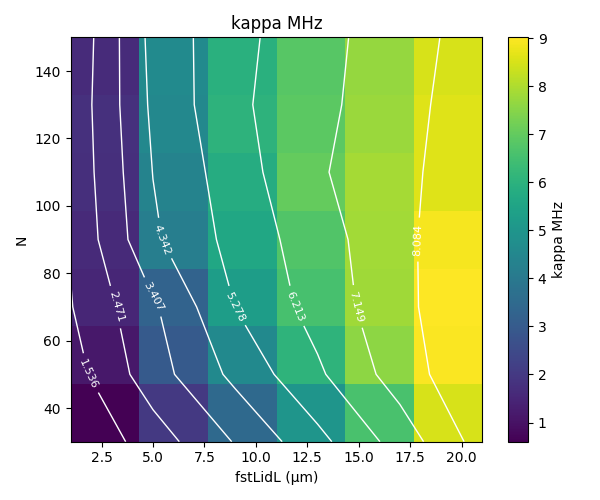

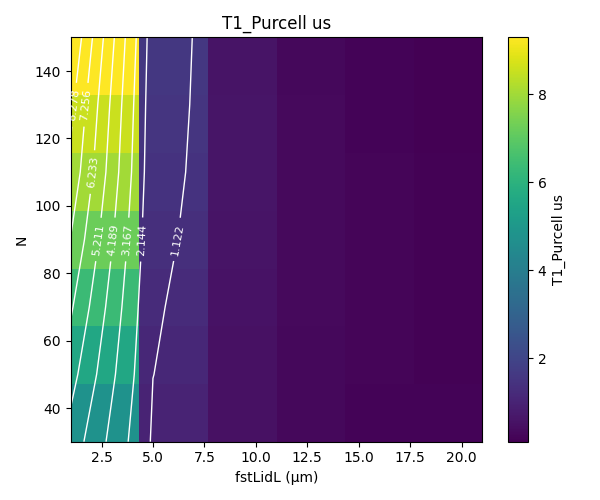

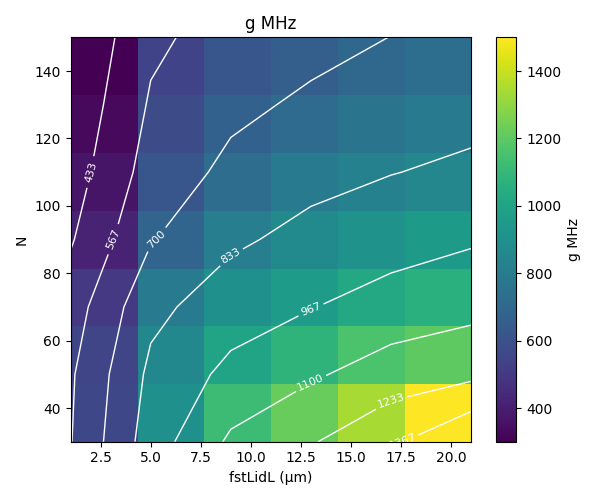

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("chain_resonator_data_first_lid_equals_last_lid.csv")

params = [
    "Cc_first","Cc_last","Cc_middle",
    "Cg_first","Cg_last","Cg_middle",
    "f1 GHz","kappa MHz","T1_Purcell us","g MHz"
]

N_vals = np.sort(df["N"].unique())
lid_vals = np.sort(df["fstLidL"].unique())

X, Y = np.meshgrid(lid_vals, N_vals)

for p in params:

    pivot = df.pivot(index="N", columns="fstLidL", values=p)
    Z = pivot.values

    plt.figure(figsize=(6,5))

    # heatmap
    im = plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[lid_vals.min(), lid_vals.max(), N_vals.min(), N_vals.max()]
    )

    # contour lines
    levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 10)
    cs = plt.contour(X, Y, Z, levels=levels, colors="white", linewidths=1)

    # contour labels
    plt.clabel(cs, inline=True, fontsize=8)

    plt.colorbar(im, label=p)

    plt.xlabel("fstLidL (µm)")
    plt.ylabel("N")
    plt.title(p)

    plt.tight_layout()
    plt.show()